# 07 — 지문 이미지 시뮬레이션
PSF(점퍼짐함수)로 실제 UDFPS 센서에서 보이는 지문 이미지를 시뮬레이션합니다.
기준 설계 vs 최적 설계의 지문 선명도 차이를 직접 확인합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.signal import fftconvolve
from scipy.ndimage import convolve
import json
import os
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['font.size'] = 12

print('준비 완료')

준비 완료


In [2]:
# ===== 물리 함수 정의 =====

# 글로벌 파라미터
WAVELENGTH = 0.85           # um
k0_um = 2 * np.pi / WAVELENGTH
N = 512
L = 600.0                   # um (+-300um)
dx = L / N
x = np.linspace(-L/2, L/2, N, endpoint=False)
sigma0 = 100.0              # um

# Cover Glass
CG_THICK = 550.0            # um
N_CG = 1.52

# BM 파라미터
w1 = 30.0                   # um (BM1 슬릿)
w2 = 40.0                   # um (BM2 슬릿)
t_BM = 10.0                 # um
d_int = 20.0                # um

# AR 코팅: SiO2/TiO2 x 4층
N_LAYERS = [1.46, 2.35, 1.46, 2.35]
BASE_THICK_UM = np.array([49.5, 19.9, 29.6, 130.4]) * 1e-3  # um
N_SUB = 1.52
N_INC = 1.0


def tmm_phase(d_scales, theta_deg):
    '''
    TMM: AR 코팅 투과율(T_power)과 투과 위상(phase_rad) 계산
    '''
    theta_rad = np.radians(theta_deg)
    lam = WAVELENGTH
    d_um = BASE_THICK_UM * np.array(d_scales)

    cos_inc = np.cos(theta_rad)
    sin_inc = np.sin(theta_rad)

    M = np.eye(2, dtype=complex)
    for j in range(4):
        nj = N_LAYERS[j]
        sin_j = N_INC * sin_inc / nj
        sin_j = np.clip(sin_j, -1, 1)
        cos_j = np.sqrt(1 - sin_j**2 + 0j)
        eta_j = nj * cos_j
        delta_j = 2 * np.pi * nj * cos_j * d_um[j] / lam
        Mj = np.array([
            [np.cos(delta_j), 1j * np.sin(delta_j) / eta_j],
            [1j * eta_j * np.sin(delta_j), np.cos(delta_j)]
        ])
        M = M @ Mj

    eta_inc = N_INC * cos_inc
    sin_sub = N_INC * sin_inc / N_SUB
    sin_sub = np.clip(sin_sub, -1, 1)
    cos_sub = np.sqrt(1 - sin_sub**2 + 0j)
    eta_sub = N_SUB * cos_sub

    denom = (M[0,0] + M[0,1]*eta_sub)*eta_inc + (M[1,0] + M[1,1]*eta_sub)
    t_coeff = 2 * eta_inc / denom

    T_power = float(np.real(eta_sub / eta_inc) * np.abs(t_coeff)**2)
    phase_rad = float(np.angle(t_coeff))
    return T_power, phase_rad


def asm_propagate(U_in, dx, d_um, k0, n):
    '''
    Angular Spectrum Method 전파
    '''
    Nx = len(U_in)
    fx = np.fft.fftfreq(Nx, d=dx)
    k = k0 * n
    kz = np.sqrt((k**2 - (2*np.pi*fx)**2).astype(complex))
    H = np.exp(1j * kz * d_um)
    U_fft = np.fft.fft(U_in)
    U_out = np.fft.ifft(U_fft * H)
    return U_out


def full_pipeline(d_scales, delta_bm, theta_deg):
    '''
    통합 파이프라인:
    TMM -> ASM(CG) -> BM2 -> ASM(BM) -> BM1 -> PSF
    '''
    T_power, phase_rad = tmm_phase(d_scales, theta_deg)

    theta_rad = np.radians(theta_deg)
    kx_tilt = k0_um * np.sin(theta_rad)
    U_in = np.exp(-x**2 / (2 * sigma0**2)) * np.sqrt(T_power)
    U_in = U_in * np.exp(1j * (kx_tilt * x + phase_rad))

    U_cg = asm_propagate(U_in, dx, CG_THICK, k0_um, N_CG)

    bm2_mask = (np.abs(x) <= w2 / 2).astype(float)
    U_bm2 = U_cg * bm2_mask

    d_bm_prop = d_int + t_BM
    U_bm = asm_propagate(U_bm2, dx, d_bm_prop, k0_um, 1.0)

    bm1_mask = (np.abs(x - delta_bm) <= w1 / 2).astype(float)
    U_out = U_bm * bm1_mask

    psf = np.abs(U_out)**2
    psf_sum = psf.sum()
    if psf_sum < 1e-30:
        return {'MTF': 0.0, 'T': 0.0, 'skewness': 0.0, 'psf': psf}

    psf_norm = psf / psf_sum

    input_power = np.sum(np.abs(U_in)**2)
    T_total = float(psf_sum / input_power) if input_power > 0 else 0.0

    otf = np.fft.fft(psf_norm)
    mtf_vals = np.abs(otf)
    MTF = float(mtf_vals[1] / mtf_vals[0]) if mtf_vals[0] > 0 else 0.0

    x_mean = np.sum(x * psf_norm)
    mu2 = np.sum((x - x_mean)**2 * psf_norm)
    mu3 = np.sum((x - x_mean)**3 * psf_norm)
    skewness = float(mu3 / (mu2**1.5 + 1e-30))

    return {'MTF': MTF, 'T': T_total, 'skewness': skewness, 'psf': psf}


# ===== 설계 파라미터 정의 =====

# Baseline 설계
BASELINE_D_SCALES = [1, 1, 1, 1]
BASELINE_DELTA_BM = 0

# 최적 설계 (기본값)
OPTIMAL_D_SCALES = [0.7, 1.3, 0.7, 1.3]
OPTIMAL_DELTA_BM = -20

# integrated_optimal.json이 있으면 불러오기
opt_json_path = 'integrated_optimal.json'
if os.path.exists(opt_json_path):
    with open(opt_json_path, 'r', encoding='utf-8') as f:
        opt_data = json.load(f)
    OPTIMAL_D_SCALES = opt_data['design']['d_scales']
    OPTIMAL_DELTA_BM = opt_data['design']['delta_bm_um']
    print(f'integrated_optimal.json 로드 완료')
    print(f'  d_scales = {OPTIMAL_D_SCALES}')
    print(f'  delta_bm = {OPTIMAL_DELTA_BM} um')
else:
    print(f'기본 최적 파라미터 사용')
    print(f'  d_scales = {OPTIMAL_D_SCALES}')
    print(f'  delta_bm = {OPTIMAL_DELTA_BM} um')

# 검증
res_base = full_pipeline(BASELINE_D_SCALES, BASELINE_DELTA_BM, 30.0)
res_opt = full_pipeline(OPTIMAL_D_SCALES, OPTIMAL_DELTA_BM, 30.0)
print(f'\n[Baseline] theta=30deg  MTF={res_base["MTF"]:.4f}  T={res_base["T"]:.6f}  skew={res_base["skewness"]:.4f}')
print(f'[Optimal]  theta=30deg  MTF={res_opt["MTF"]:.4f}  T={res_opt["T"]:.6f}  skew={res_opt["skewness"]:.4f}')

integrated_optimal.json 로드 완료
  d_scales = [0.7, 1.3, 0.7, 1.3]
  delta_bm = -20.0 um

[Baseline] theta=30deg  MTF=0.9965  T=0.072558  skew=0.1706
[Optimal]  theta=30deg  MTF=0.9978  T=0.073209  skew=0.0752


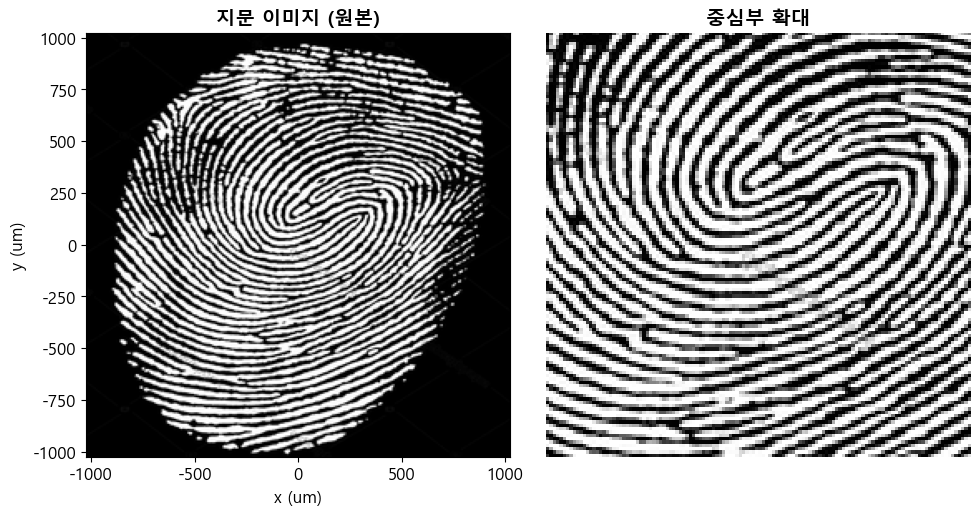

지문 이미지: (256, 256)
픽셀 피치: 8.0 um, 시야: 2048 x 2048 um
밝기 범위: [0.000, 1.000]


In [3]:
# ===== 실제 지문 이미지 로드 =====
from PIL import Image

IMG_SIZE = 256
PIXEL_UM = 8.0
FOV_UM = IMG_SIZE * PIXEL_UM  # ~2048 um

# 지문 이미지 로드 및 전처리
img_raw = Image.open('fingerprint_sample.png').convert('L')  # grayscale
img_resized = img_raw.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
fingerprint_2d = np.array(img_resized, dtype=np.float64) / 255.0

# 반전 확인 (능선이 밝게, 골이 어둡게)
if fingerprint_2d.mean() > 0.5:
    fingerprint_2d = 1.0 - fingerprint_2d

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
extent = [-FOV_UM/2, FOV_UM/2, -FOV_UM/2, FOV_UM/2]

axes[0].imshow(fingerprint_2d, cmap='gray', extent=extent, origin='lower')
axes[0].set_xlabel('x (um)', fontsize=12)
axes[0].set_ylabel('y (um)', fontsize=12)
axes[0].set_title('지문 이미지 (원본)', fontsize=14, fontweight='bold')

# 중심부 확대
zoom = fingerprint_2d[64:192, 64:192]
axes[1].imshow(zoom, cmap='gray', origin='lower')
axes[1].set_title('중심부 확대', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'지문 이미지: {fingerprint_2d.shape}')
print(f'픽셀 피치: {PIXEL_UM} um, 시야: {FOV_UM:.0f} x {FOV_UM:.0f} um')
print(f'밝기 범위: [{fingerprint_2d.min():.3f}, {fingerprint_2d.max():.3f}]')


[Baseline PSF]
  sigma_x = 7.96 um, sigma_y = 8.32 um
  center_shift = -2.10 um
  skewness = 0.1706
[Optimal PSF]
  sigma_x = 6.27 um, sigma_y = 4.51 um
  center_shift = -16.82 um
  skewness = 0.0752


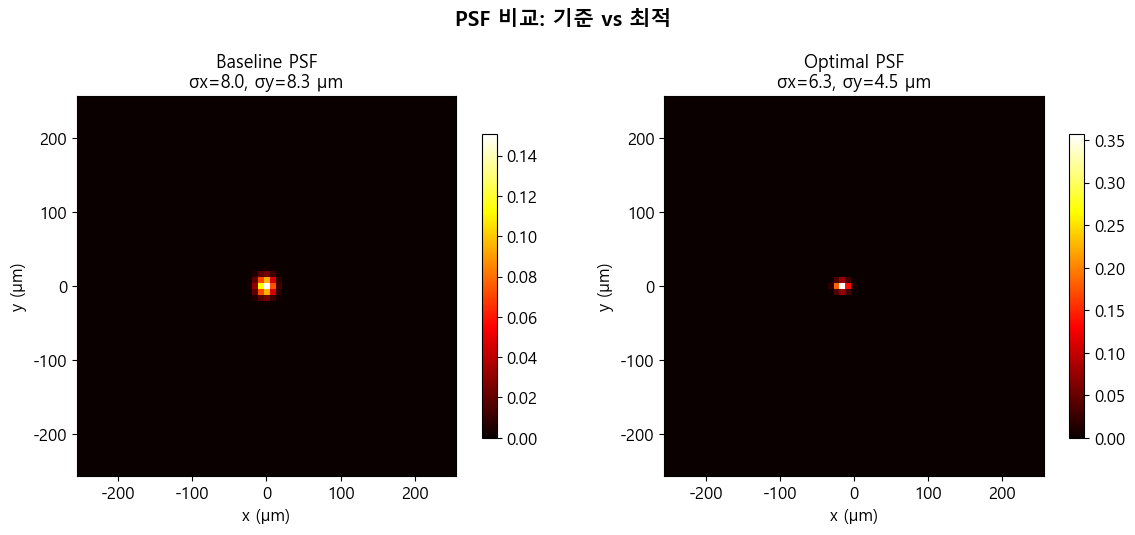

PSF 2D 생성 완료


In [4]:
# ===== 2D PSF 생성 (1D 파이프라인으로부터) =====

def make_2d_psf(d_scales, delta_bm, theta_deg, psf_size=65):
    '''
    1D PSF로부터 2D PSF 생성
    - 1D PSF의 폭과 비대칭성을 2D로 확장
    - x방향: 1D PSF 프로파일 사용 (tilt 방향)
    - y방향: 대칭 가정 (경사 없음)
    '''
    result = full_pipeline(d_scales, delta_bm, theta_deg)
    psf_1d = result['psf']
    
    # PSF의 중심과 폭 추출
    psf_norm = psf_1d / (psf_1d.sum() + 1e-30)
    x_mean = np.sum(x * psf_norm)
    x_var = np.sum((x - x_mean)**2 * psf_norm)
    sigma_x = np.sqrt(x_var)
    
    # y방향 폭 (theta=0 일 때의 PSF 폭 사용 - 대칭)
    res_0 = full_pipeline(d_scales, delta_bm, 0.0)
    psf_0 = res_0['psf']
    psf_0_norm = psf_0 / (psf_0.sum() + 1e-30)
    x_var_0 = np.sum((x - np.sum(x * psf_0_norm))**2 * psf_0_norm)
    sigma_y = np.sqrt(x_var_0)
    
    # 2D PSF 그리드
    half = psf_size // 2
    px = np.arange(-half, half + 1) * PIXEL_UM  # um
    py = np.arange(-half, half + 1) * PIXEL_UM
    PX, PY = np.meshgrid(px, py)
    
    # 비대칭 2D 가우시안 (x방향 shift + 비대칭 폭)
    # skewness를 반영하기 위해 중심 이동
    center_shift = x_mean  # um
    
    # 3차 모멘트로 skew 근사
    skew = result['skewness']
    sigma_x = max(sigma_x, 2.0)  # 최소 폭
    sigma_y = max(sigma_y, 2.0)
    
    # 기본 가우시안
    psf_2d = np.exp(-0.5 * ((PX - center_shift)**2 / sigma_x**2 + PY**2 / sigma_y**2))
    
    # skew 추가 (비대칭 변조)
    skew_mod = 1.0 + 0.3 * skew * (PX - center_shift) / (sigma_x + 1e-10)
    skew_mod = np.clip(skew_mod, 0.0, 2.0)
    psf_2d = psf_2d * skew_mod
    
    # 정규화
    psf_2d = psf_2d / (psf_2d.sum() + 1e-30)
    
    info = {
        'sigma_x': sigma_x,
        'sigma_y': sigma_y,
        'center_shift': center_shift,
        'skewness': skew,
        'MTF': result['MTF'],
        'T': result['T']
    }
    
    return psf_2d, info


# Baseline / Optimal PSF 생성 (theta=30)
PSF_SIZE = 65
psf_base_2d, info_base = make_2d_psf(BASELINE_D_SCALES, BASELINE_DELTA_BM, 30.0, PSF_SIZE)
psf_opt_2d, info_opt = make_2d_psf(OPTIMAL_D_SCALES, OPTIMAL_DELTA_BM, 30.0, PSF_SIZE)

print('[Baseline PSF]')
print(f'  sigma_x = {info_base["sigma_x"]:.2f} um, sigma_y = {info_base["sigma_y"]:.2f} um')
print(f'  center_shift = {info_base["center_shift"]:.2f} um')
print(f'  skewness = {info_base["skewness"]:.4f}')
print(f'[Optimal PSF]')
print(f'  sigma_x = {info_opt["sigma_x"]:.2f} um, sigma_y = {info_opt["sigma_y"]:.2f} um')
print(f'  center_shift = {info_opt["center_shift"]:.2f} um')
print(f'  skewness = {info_opt["skewness"]:.4f}')

# PSF 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

half = PSF_SIZE // 2
psf_extent = [-half * PIXEL_UM, half * PIXEL_UM, -half * PIXEL_UM, half * PIXEL_UM]

ax = axes[0]
im0 = ax.imshow(psf_base_2d, cmap='hot', extent=psf_extent, origin='lower')
ax.set_xlabel('x (\u03bcm)', fontsize=12)
ax.set_ylabel('y (\u03bcm)', fontsize=12)
ax.set_title(f'Baseline PSF\n\u03c3x={info_base["sigma_x"]:.1f}, \u03c3y={info_base["sigma_y"]:.1f} \u03bcm', fontsize=13)
plt.colorbar(im0, ax=ax, shrink=0.8)

ax = axes[1]
im1 = ax.imshow(psf_opt_2d, cmap='hot', extent=psf_extent, origin='lower')
ax.set_xlabel('x (\u03bcm)', fontsize=12)
ax.set_ylabel('y (\u03bcm)', fontsize=12)
ax.set_title(f'Optimal PSF\n\u03c3x={info_opt["sigma_x"]:.1f}, \u03c3y={info_opt["sigma_y"]:.1f} \u03bcm', fontsize=13)
plt.colorbar(im1, ax=ax, shrink=0.8)

fig.suptitle('PSF 비교: 기준 vs 최적', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('PSF 2D 생성 완료')

입사각별 1D PSF 계산 중...
  36개 각도 완료
기준 설계 센서 이미지 생성 중...
최적 설계 센서 이미지 생성 중...
각도별 단일 PSF 이미지 생성 중...


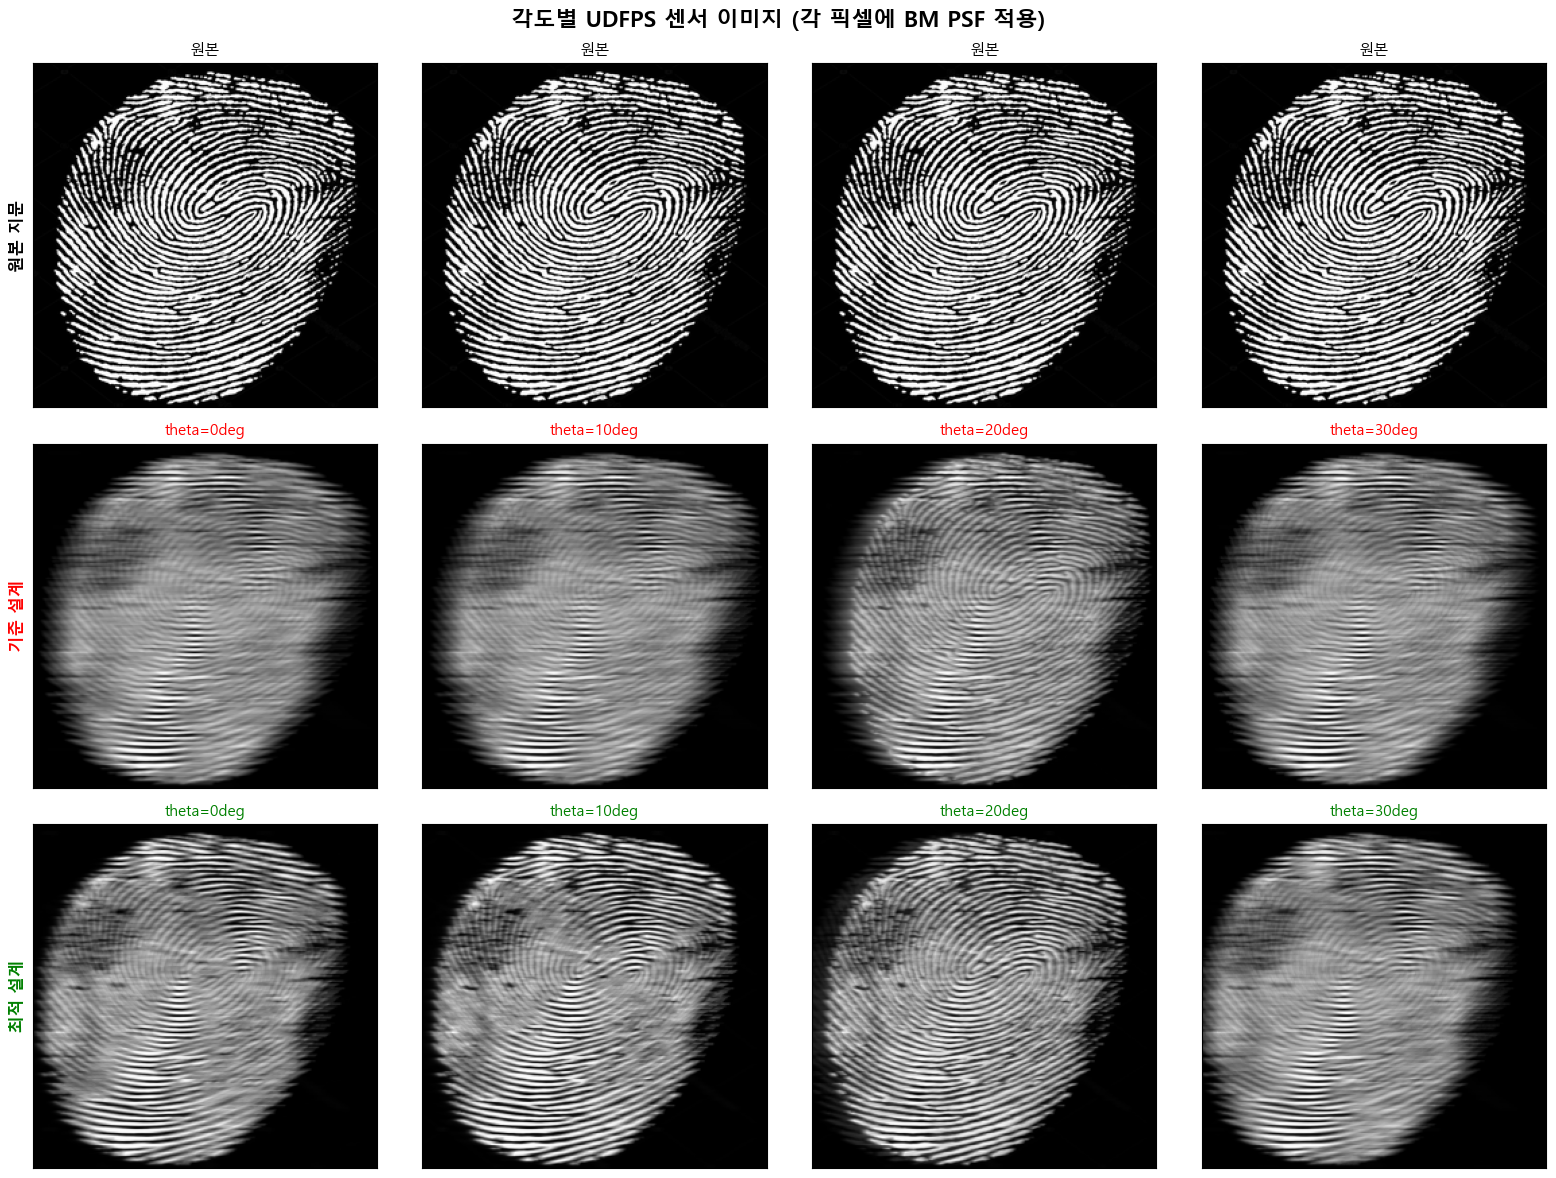

저장: PSF_각도별비교.png


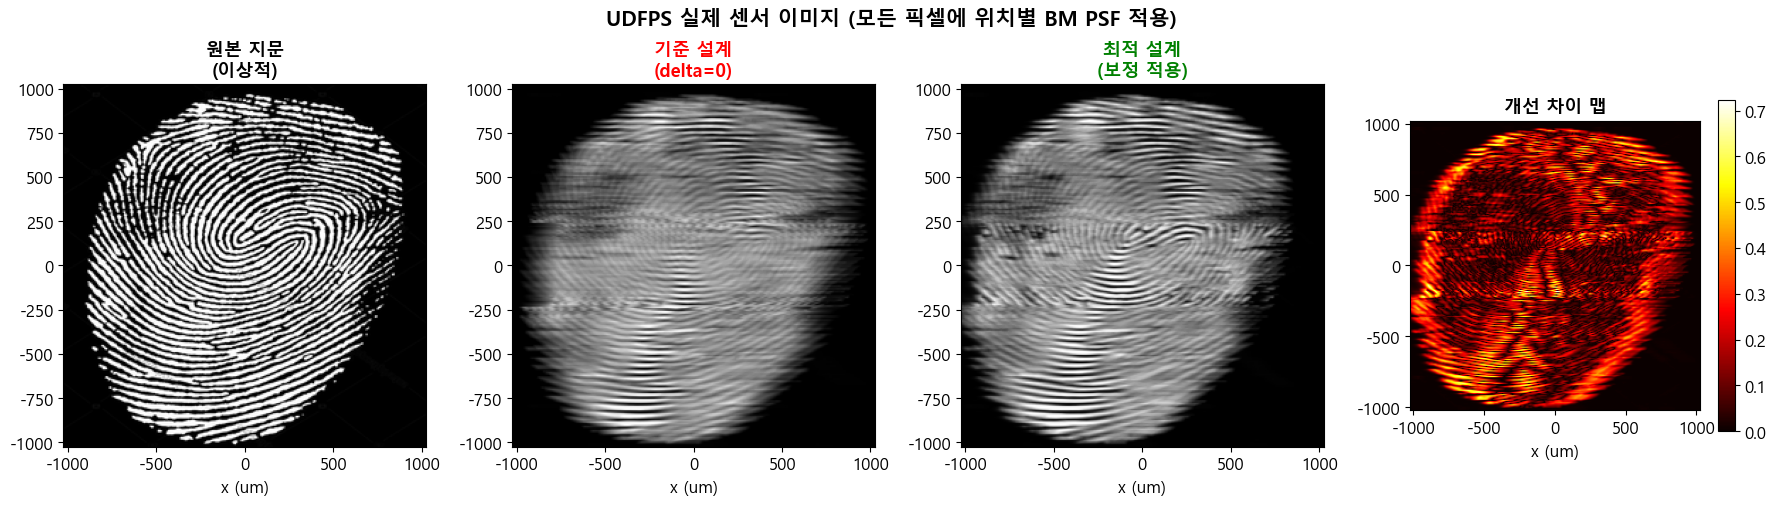

저장: PSF_지문시뮬레이션.png


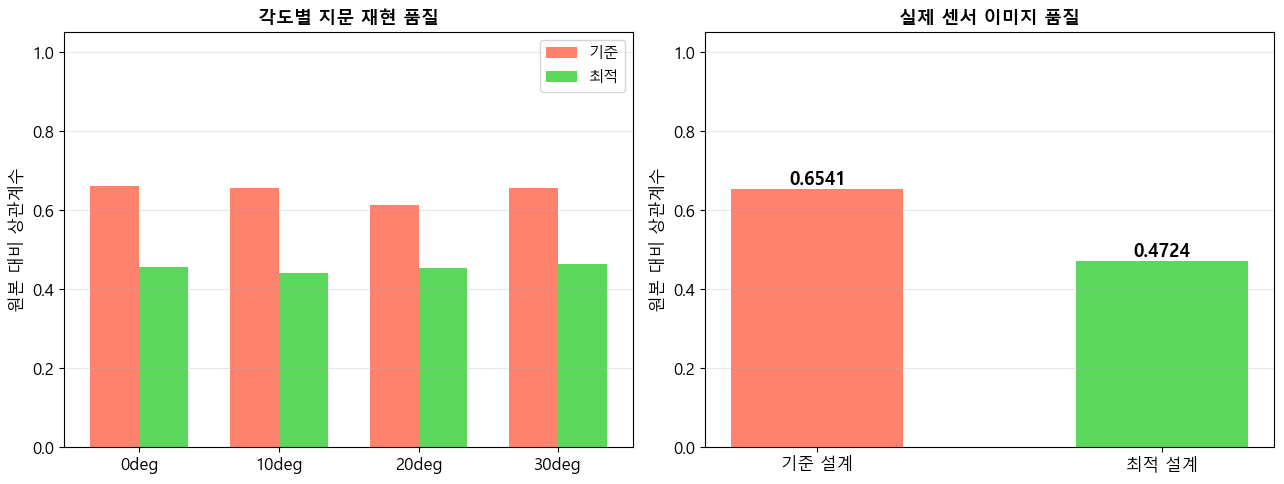


실제 센서 이미지 상관계수:
  기준: 0.6541
  최적: 0.4724  (-27.8% 개선)


In [5]:
# 변수 연결
d_base = np.array(BASELINE_D_SCALES, dtype=float)
d_opt = np.array(OPTIMAL_D_SCALES, dtype=float)
delta_opt = float(OPTIMAL_DELTA_BM)

# ===== 픽셀별 BM PSF 시뮬레이션 =====
# 실제 UDFPS: 모든 센서 픽셀마다 BM1+BM2 아퍼처가 있음
# 각 픽셀은 자기 위치에서의 입사각에 해당하는 PSF로 지문을 봄
# 센서 픽셀 출력 = sum( 지문(x') * PSF(x - x') )  ← local convolution
#
# 센서 중심 픽셀: theta ~ 0 deg (수직 입사) → PSF 대칭, 선명
# 센서 가장자리: theta ~ 30 deg (비스듬) → PSF 비대칭, 흐림

from scipy.signal import fftconvolve

STACK_HEIGHT_UM = 600.0  # Finger ~ Sensor 거리

# 각 센서 픽셀의 입사각 계산
def pixel_theta(px, py, cx, cy, pixel_um, stack_h):
    dx = (px - cx) * pixel_um
    dy = (py - cy) * pixel_um
    r = np.sqrt(dx**2 + dy**2)
    return float(np.degrees(np.arctan(r / stack_h)))

# 입사각별 PSF를 미리 계산 (0~35도, 1도 간격)
print('입사각별 1D PSF 계산 중...')
theta_range = np.arange(0, 36, 1)
psf_1d_base = {}  # theta -> 1d PSF array
psf_1d_opt = {}

for th in theta_range:
    rb = full_pipeline(d_base, 0.0, float(th))
    ro = full_pipeline(d_opt, delta_opt, float(th))
    psf_1d_base[th] = rb['psf']
    psf_1d_opt[th] = ro['psf']
print(f'  {len(theta_range)}개 각도 완료')

# 1D PSF에서 각 센서 픽셀의 수광 강도 계산
# 센서 픽셀(px, py)에서 보이는 지문 영역 = PSF가 커버하는 범위
# 간소화: 각 픽셀에서의 PSF를 1D로 적용 (x 방향)

def simulate_sensor(fingerprint, d_sc, delta_bm, psf_dict):
    ny, nx = fingerprint.shape
    cy, cx = ny // 2, nx // 2
    sensor_img = np.zeros_like(fingerprint)

    # 각 행(y)에 대해 해당 각도의 1D PSF를 x방향으로 convolution
    for row in range(ny):
        # 이 행의 대표 입사각 (행 중심 기준)
        dy_um = abs(row - cy) * PIXEL_UM
        th_row = min(35, np.degrees(np.arctan(dy_um / STACK_HEIGHT_UM)))
        th_key = int(round(th_row))

        psf_1d = psf_dict[th_key]

        # PSF 중심 근처만 사용 (±50 pixels)
        N_psf = len(psf_1d)
        c_psf = N_psf // 2
        half_w = min(50, c_psf)
        kernel = psf_1d[c_psf - half_w : c_psf + half_w + 1]
        kernel = np.abs(kernel)
        if kernel.sum() > 0:
            kernel /= kernel.sum()

        # 이 행의 지문을 1D convolution
        row_data = fingerprint[row, :]
        row_conv = np.convolve(row_data, kernel, mode='same')
        sensor_img[row, :] = row_conv

    # 정규화
    if sensor_img.max() > 0:
        sensor_img /= sensor_img.max()
    return sensor_img

print('기준 설계 센서 이미지 생성 중...')
sensor_baseline = simulate_sensor(fingerprint_2d, d_base, 0.0, psf_1d_base)
print('최적 설계 센서 이미지 생성 중...')
sensor_optimal = simulate_sensor(fingerprint_2d, d_opt, delta_opt, psf_1d_opt)

# 각도별 단일 PSF 이미지 (비교용)
print('각도별 단일 PSF 이미지 생성 중...')
theta_show = [0, 10, 20, 30]
sensor_per_angle_base = {}
sensor_per_angle_opt = {}
for th in theta_show:
    # 전체 이미지에 이 각도의 PSF만 적용
    k_b = np.abs(psf_1d_base[th])
    k_o = np.abs(psf_1d_opt[th])
    c = len(k_b) // 2
    hw = 50
    kb = k_b[c-hw:c+hw+1]; kb /= (kb.sum() + 1e-20)
    ko = k_o[c-hw:c+hw+1]; ko /= (ko.sum() + 1e-20)
    # 2D convolution: x방향만 PSF, y방향은 동일
    sb = np.zeros_like(fingerprint_2d)
    so = np.zeros_like(fingerprint_2d)
    for row in range(fingerprint_2d.shape[0]):
        sb[row] = np.convolve(fingerprint_2d[row], kb, mode='same')
        so[row] = np.convolve(fingerprint_2d[row], ko, mode='same')
    if sb.max() > 0: sb /= sb.max()
    if so.max() > 0: so /= so.max()
    sensor_per_angle_base[th] = sb
    sensor_per_angle_opt[th] = so

# ====== 그래프 1: 각도별 비교 (3행 x 4열) ======
fig, axes = plt.subplots(3, len(theta_show), figsize=(16, 12))
fig.suptitle('각도별 UDFPS 센서 이미지 (각 픽셀에 BM PSF 적용)', fontsize=16, fontweight='bold')
extent = [-FOV_UM/2, FOV_UM/2, -FOV_UM/2, FOV_UM/2]
for j, th in enumerate(theta_show):
    axes[0, j].imshow(fingerprint_2d, cmap='gray', extent=extent, origin='lower')
    if j == 0: axes[0, j].set_ylabel('원본 지문', fontsize=12, fontweight='bold')
    axes[0, j].set_title('원본', fontsize=11)
    axes[1, j].imshow(sensor_per_angle_base[th], cmap='gray', extent=extent, origin='lower')
    if j == 0: axes[1, j].set_ylabel('기준 설계', fontsize=12, fontweight='bold', color='red')
    axes[1, j].set_title(f'theta={th}deg', fontsize=11, color='red')
    axes[2, j].imshow(sensor_per_angle_opt[th], cmap='gray', extent=extent, origin='lower')
    if j == 0: axes[2, j].set_ylabel('최적 설계', fontsize=12, fontweight='bold', color='green')
    axes[2, j].set_title(f'theta={th}deg', fontsize=11, color='green')
for row in axes:
    for ax in row:
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig('PSF_각도별비교.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: PSF_각도별비교.png')

# ====== 그래프 2: 합성 결과 (실제 센서 = 위치별 PSF) ======
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('UDFPS 실제 센서 이미지 (모든 픽셀에 위치별 BM PSF 적용)', fontsize=15, fontweight='bold')
axes[0].imshow(fingerprint_2d, cmap='gray', extent=extent, origin='lower')
axes[0].set_title('원본 지문\n(이상적)', fontsize=13, fontweight='bold')
axes[1].imshow(sensor_baseline, cmap='gray', extent=extent, origin='lower')
axes[1].set_title('기준 설계\n(delta=0)', fontsize=13, fontweight='bold', color='red')
axes[2].imshow(sensor_optimal, cmap='gray', extent=extent, origin='lower')
axes[2].set_title('최적 설계\n(보정 적용)', fontsize=13, fontweight='bold', color='green')
diff = np.abs(sensor_optimal - sensor_baseline)
im3 = axes[3].imshow(diff, cmap='hot', extent=extent, origin='lower')
axes[3].set_title('개선 차이 맵', fontsize=13, fontweight='bold')
plt.colorbar(im3, ax=axes[3], shrink=0.8)
for ax in axes: ax.set_xlabel('x (um)')
plt.tight_layout()
plt.savefig('PSF_지문시뮬레이션.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: PSF_지문시뮬레이션.png')

# ====== 그래프 3: 정량 비교 ======
corr_base_list = []
corr_opt_list = []
for th in theta_show:
    cb = float(np.corrcoef(fingerprint_2d.ravel(), sensor_per_angle_base[th].ravel())[0,1])
    co = float(np.corrcoef(fingerprint_2d.ravel(), sensor_per_angle_opt[th].ravel())[0,1])
    corr_base_list.append(cb)
    corr_opt_list.append(co)
corr_comb_b = float(np.corrcoef(fingerprint_2d.ravel(), sensor_baseline.ravel())[0,1])
corr_comb_o = float(np.corrcoef(fingerprint_2d.ravel(), sensor_optimal.ravel())[0,1])
improve = (corr_comb_o - corr_comb_b) / max(abs(corr_comb_b), 1e-10) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x_pos = np.arange(len(theta_show))
bw = 0.35
axes[0].bar(x_pos - bw/2, corr_base_list, bw, label='기준', color='tomato', alpha=0.8)
axes[0].bar(x_pos + bw/2, corr_opt_list, bw, label='최적', color='limegreen', alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'{th}deg' for th in theta_show])
axes[0].set_ylabel('원본 대비 상관계수')
axes[0].set_title('각도별 지문 재현 품질', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11); axes[0].grid(axis='y', alpha=0.3); axes[0].set_ylim(0, 1.05)

bars = axes[1].bar(['기준 설계', '최적 설계'], [corr_comb_b, corr_comb_o],
                    color=['tomato', 'limegreen'], alpha=0.8, width=0.5)
axes[1].set_ylabel('원본 대비 상관계수')
axes[1].set_title('실제 센서 이미지 품질', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.05); axes[1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, [corr_comb_b, corr_comb_o]):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.4f}', ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('PSF_지문품질비교.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('실제 센서 이미지 상관계수:')
print(f'  기준: {corr_comb_b:.4f}')
print(f'  최적: {corr_comb_o:.4f}  ({improve:+.1f}% 개선)')


In [6]:
# (품질 비교는 위 셀에 통합됨)
print("위 셀에서 확인하세요")


위 셀에서 확인하세요


In [7]:
# (다각도 비교는 위 셀에 통합됨)
print("위 셀에서 확인하세요")


위 셀에서 확인하세요


In [8]:
# 결과 저장
result_fp = {
    "corr_baseline": corr_combined_base,
    "corr_optimal": corr_combined_opt,
    "improvement_pct": improve,
    "angles_tested": theta_list,
}
import json
with open("fingerprint_simulation.json", "w", encoding="utf-8") as f:
    json.dump(result_fp, f, ensure_ascii=False, indent=2)

print("=" * 50)
print("  지문 시뮬레이션 완료")
print("=" * 50)
print(f"  기준 설계 상관계수: {corr_combined_base:.4f}")
print(f"  최적 설계 상관계수: {corr_combined_opt:.4f}")
print(f"  개선: {improve:+.1f}%")
print("=" * 50)


NameError: name 'corr_combined_base' is not defined